# Multiple Linear Regression (example)

### Creating and visualizing dataset

In [1]:
import numpy as np
import pandas as pd

from sklearn.datasets import make_regression

import plotly.express as px
import plotly.graph_objects as go

In [2]:
x, y = make_regression(n_samples=200, n_features=2, n_informative=2, n_targets=1, noise=50)

In [3]:
df = pd.DataFrame({'feature1':x[:,0], 'feature2':x[:,1], 'target':y})

In [4]:
df.shape

(200, 3)

In [5]:
df.sample(5)

,feature1,feature2,target
57,2.074391,-0.329217,34.059307
199,0.026995,0.117645,81.497905
126,0.224042,0.626986,120.224551
88,1.406985,0.478246,120.829714
131,-1.483550,-0.309470,15.774570


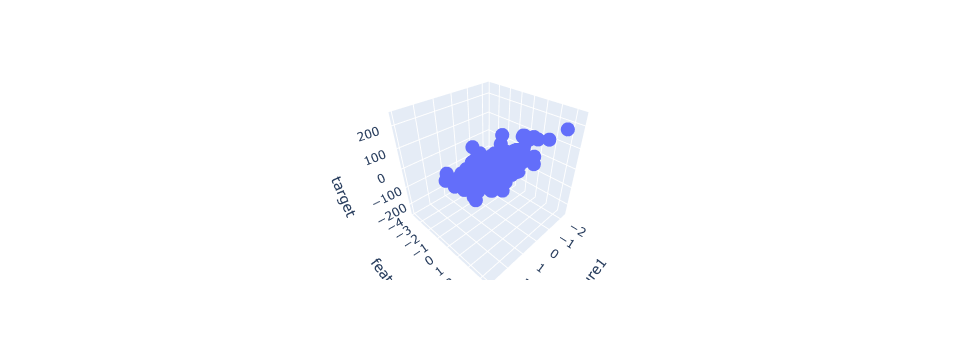

In [6]:
fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')
fig.show()

### Training **linearRegression(multiple)** model on our data

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [8]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=1)

In [9]:
x_train.shape

(160, 2)

In [10]:
multiple_lr = LinearRegression()

In [11]:
multiple_lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [12]:
y_pred = multiple_lr.predict(x_test)

### Checking performance metrics

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [14]:
print(f'Mean Absolute Error: {mean_absolute_error(y_pred, y_test)}')
print(f'Mean Squared Error: {mean_squared_error(y_pred, y_test)}')
print(f'R2 Score: {r2_score(y_pred, y_test)}')

Mean Absolute Error: 35.90696140888741
Mean Squared Error: 2294.024817729227
R2 Score: 0.5122262718048718


### Visualizing our plane that separates data

In [17]:
x = np.linspace(-5, 5, 10)
y = np.linspace(-5, 5, 10)
xGrid, yGrid = np.meshgrid(y, x)
final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T

z_final = multiple_lr.predict(final).reshape(10,10)

z = z_final

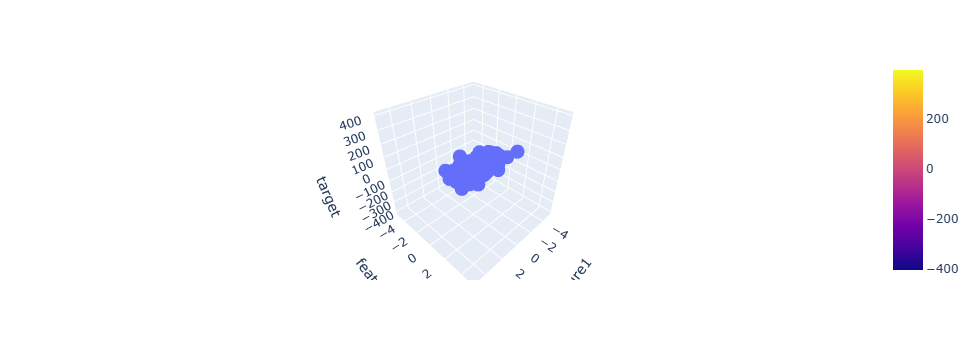

In [18]:
fig = px.scatter_3d(df, x='feature1', y='feature2', z='target')

fig.add_trace(go.Surface(x = x, y = y, z =z ))

fig.show()

### Value of constants

In [20]:
multiple_lr.coef_   # Will give value of w1, and w2

array([17.88684747, 62.10311746])

In [21]:
multiple_lr.intercept_   # Will give the value of w0

np.float64(-3.6209677339616064)